# Transfer learning


In [32]:
import sys, json, os, importlib
sys.path.append('../')
import tensorflow as tf
import tensorflow.keras.backend as K
import utils.models as models
import utils.training as training_utils
import utils.utils as gen_utils

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
import pickle

import utils.predictions as predictions

In [50]:
importlib.reload(gen_utils)

fil_path = '../data/Trap_sims'
dist = 'negbin'

gen_utils.merge_for_training(fil_path, dist)


,Location,Year,Month,Day,Avg_Temp,Precip,Humidity,weekly_mean,weekly_var
0,Arboleda,2013,3,3,24.613170,0.073242,79.754791,NaN,NaN
1,Arboleda,2013,3,4,25.217322,0.063577,75.734895,NaN,NaN
2,Arboleda,2013,3,5,24.578496,0.052771,73.316999,NaN,NaN
3,Arboleda,2013,3,6,24.519198,0.065027,72.704373,NaN,NaN
4,Arboleda,2013,3,7,24.631753,0.074842,76.725745,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9398,San_Juan,2019,12,28,26.750000,0.000000,79.000000,3.1,6.581633
9399,San_Juan,2019,12,29,26.660000,0.050800,80.000000,NaN,NaN
9400,San_Juan,2019,12,30,26.780000,1.625600,80.000000,NaN,NaN
9401,San_Juan,2019,12,31,27.320000,0.355600,85.000000,NaN,NaN


In [54]:
importlib.reload(gen_utils)
fpath= '../utils/model_files/finetune_training_traps.csv'

print(pd.read_pickle('../utils/model_files/test_avg_data.pd'))
asdf

gen_utils.format_synthetic_for_training(fpath)

                       Location    Year Month   Day   Avg_Temp   Precip  \
0         Fairfield,Connecticut  2011.0   4.0   1.0  11.879900   1.3247   
1         Fairfield,Connecticut  2011.0   4.0   2.0   7.219650      0.0   
2         Fairfield,Connecticut  2011.0   4.0   3.0   6.921035      0.0   
3         Fairfield,Connecticut  2011.0   4.0   4.0  13.436350   1.4352   
4         Fairfield,Connecticut  2011.0   4.0   5.0  13.896550  0.34384   
...                         ...     ...   ...   ...        ...      ...   
103235  Prescott Valley,Arizona  2020.0  12.0  26.0   2.592700      0.0   
103236  Prescott Valley,Arizona  2020.0  12.0  27.0   3.574700      0.0   
103237  Prescott Valley,Arizona  2020.0  12.0  28.0   4.951050      0.0   
103238  Prescott Valley,Arizona  2020.0  12.0  29.0   5.935900      0.0   
103239  Prescott Valley,Arizona  2020.0  12.0  30.0   6.381950      0.0   

       Humidity MoLS  
0        58.715  0.0  
1        61.093  0.0  
2        40.474  0.0  
3      

NameError: name 'asdf' is not defined

In [55]:
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
importlib.reload(training_utils)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  # Restrict TensorFlow to only allocate 3GB of memory on the first GPU
  try:
    tf.config.experimental.set_virtual_device_configuration(
        gpus[0],
        [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=2*1024)])
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Virtual devices must be set before GPUs have been initialized
    print(e)

with open("../utils/model_files/gru_avg_temp_config.json") as fp:
  config=json.load(fp)

data_shape = config['data']['data_shape']
scaler = pd.read_pickle('../utils/model_files/avg_scaler.pkl')
model_file = os.path.expanduser(config['files']['model'])
if os.path.exists(model_file):
  base_model = tf.keras.models.load_model(model_file, custom_objects = {'r2_keras': predictions.r2_keras})
  print('model loaded')

for layer in base_model.layers[:-1]:
  layer.trainable=False
base_model.layers[-1].trainable = True

data = pd.read_csv('../utils/model_files/finetune_training.csv')
training = data[data.Year<2015]
testing = data[data.Year>=2015]

training = training_utils.format_data(training, config['data']['data_shape'], 2000, scaler=scaler)
#testing = training_utils.format_data(testing, config['data']['data_shape'], 2000, scaler=scaler)

X_train, y_train = training_utils.split_and_shuffle(training)
print(X_train)
asdf

# Define a callback to save the best weights
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    '../utils/model_files/transferred_model.h5', save_best_only=True, monitor='loss', mode='max', verbose=1
)

base_model.compile(optimizer = getattr(tf.keras.optimizers, config['compile']['optimizer'])(lr = 0.001),
                    loss = config['compile']['loss'], metrics = [predictions.r2_keras])
base_model.fit(X_train, y_train, epochs=500, callbacks=[checkpoint_callback])


model loaded
(1972, 90, 4)
[[[7.7972114e-01 1.6849566e-03 8.3699089e-01]
  [7.8249890e-01 2.2742394e-03 7.3737216e-01]
  [7.6971424e-01 4.8386771e-03 7.5170457e-01]
  ...
  [7.6862913e-01 2.2882756e-03 7.5279278e-01]
  [7.2662950e-01 2.3504668e-03 6.9687808e-01]
  [7.6406264e-01 0.0000000e+00 7.4082416e-01]]

 [[7.8329968e-01 8.3524399e-03 8.0570072e-01]
  [7.7066618e-01 5.9353802e-03 7.7463627e-01]
  [7.8318506e-01 8.6913034e-03 8.1091458e-01]
  ...
  [7.3181283e-01 2.6025684e-04 7.1077484e-01]
  [7.4137151e-01 1.8754455e-04 7.5779510e-01]
  [7.3949194e-01 2.2594717e-04 7.6912773e-01]]

 [[7.9027617e-01 1.3370086e-02 8.2145935e-01]
  [7.9839718e-01 0.0000000e+00 8.1638062e-01]
  [8.0337727e-01 3.1834025e-02 6.4332747e-01]
  ...
  [7.9435271e-01 1.8430594e-03 7.6935124e-01]
  [7.7910572e-01 1.2284033e-03 7.5253201e-01]
  [7.8647804e-01 1.6206321e-03 7.4554813e-01]]

 ...

 [[7.9284143e-01 1.8854153e-03 6.8511522e-01]
  [7.9700857e-01 0.0000000e+00 6.2416977e-01]
  [8.0087805e-01 0.0000

NameError: name 'asdf' is not defined

197/197 [==============================] - 3s 12ms/step


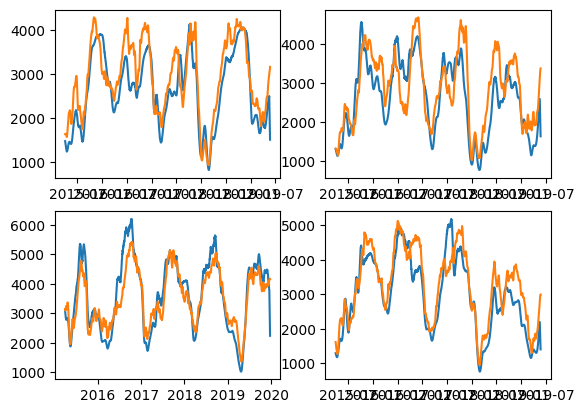

In [28]:
import importlib
importlib.reload(predictions) 
import matplotlib.pyplot as plt

model_fil = '../utils/model_files/transferred_model.h5'

model = tf.keras.models.load_model(model_file, custom_objects = {'r2_keras': predictions.r2_keras})


results = predictions.gen_preds(model, testing, data_shape, scaler, fit_scaler=False)
results = pd.DataFrame(results, columns=['Location', 'Year', 'Month', 'Day', 'MoLS', 'Neural Network'])
results['Datetime'] = pd.to_datetime(results[['Year', 'Month', 'Day']])
fig, axs = plt.subplots(2,2)
axs = axs.ravel()

for ax,loc in zip(axs,results.Location.unique()):
  subset = results[results.Location.str.contains(loc)]
  ax.plot(subset.Datetime, subset.MoLS, color='tab:blue')
  ax.plot(subset.Datetime, subset['Neural Network'], color='tab:orange')
plt.show()